In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"E:\Arya_Domain_Verse_1.0\general_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4410, 29)


,EmployeeID,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,Gender,...,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
0,1,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,...,1.0,6,1,0,0,3.0,4.0,2.0,3,3
1,2,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,Female,...,6.0,3,5,1,4,3.0,2.0,4.0,2,4
2,3,32,No,Travel_Frequently,Research & Development,17,4,Other,1,Male,...,5.0,2,5,0,3,2.0,2.0,1.0,3,3
3,4,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,Male,...,13.0,5,8,7,5,4.0,4.0,3.0,2,3
4,5,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,Male,...,9.0,2,6,0,4,4.0,1.0,3.0,3,3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   Age                      4410 non-null   int64  
 2   Attrition                4410 non-null   str    
 3   BusinessTravel           4410 non-null   str    
 4   Department               4410 non-null   str    
 5   DistanceFromHome         4410 non-null   int64  
 6   Education                4410 non-null   int64  
 7   EducationField           4410 non-null   str    
 8   EmployeeCount            4410 non-null   int64  
 9   Gender                   4410 non-null   str    
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   str    
 12  MaritalStatus            4410 non-null   str    
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked       4391 non-n

In [4]:
df["Attrition"].value_counts()

Attrition
No     3699
Yes     711
Name: count, dtype: int64

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4410
Columns: 29


In [6]:
print(df.columns.tolist())

['EmployeeID', 'Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating']


In [7]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [8]:
df.isnull().sum()

EmployeeID                  0
Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
Gender                      0
JobLevel                    0
JobRole                     0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked         19
Over18                      0
PercentSalaryHike           0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           9
TrainingTimesLastYear       0
YearsAtCompany              0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
EnvironmentSatisfaction    25
JobSatisfaction            20
WorkLifeBalance            38
JobInvolvement              0
PerformanceRating           0
dtype: int64

In [9]:
# Fill numerical missing values with median
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check again
print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [10]:
df.shape

(4410, 29)

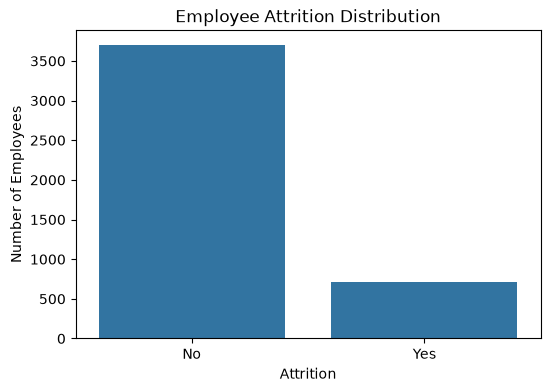

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

In [12]:
attrition_percentage = df["Attrition"].value_counts(normalize=True) * 100
print(attrition_percentage)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


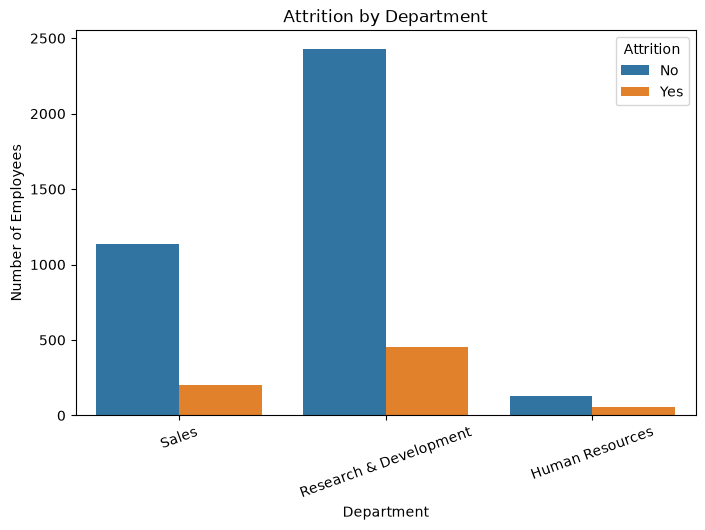

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Department", hue="Attrition")

plt.title("Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=20)
plt.show()

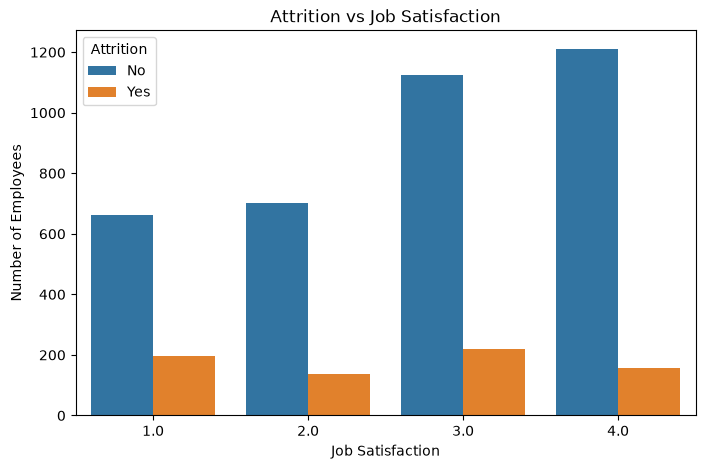

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="JobSatisfaction", hue="Attrition")

plt.title("Attrition vs Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")
plt.show()

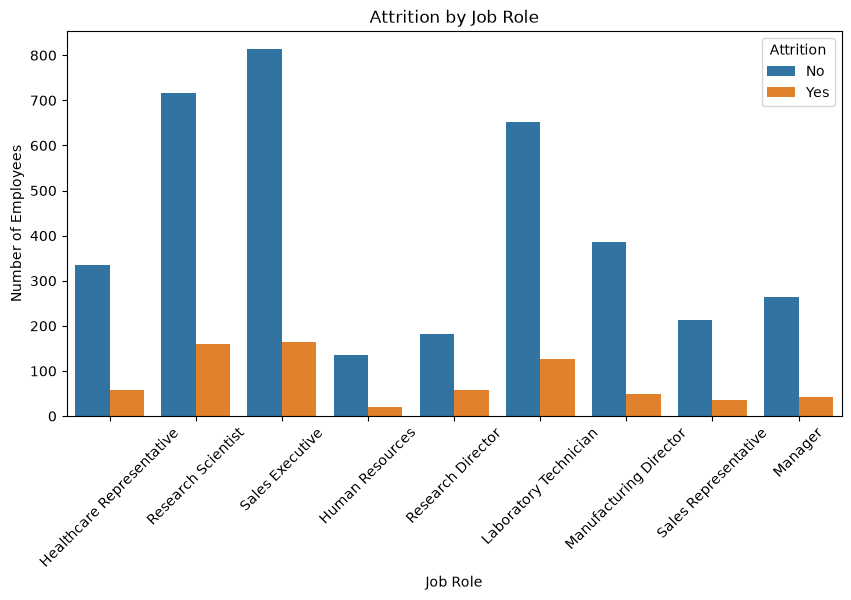

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="JobRole", hue="Attrition")

plt.title("Attrition by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()

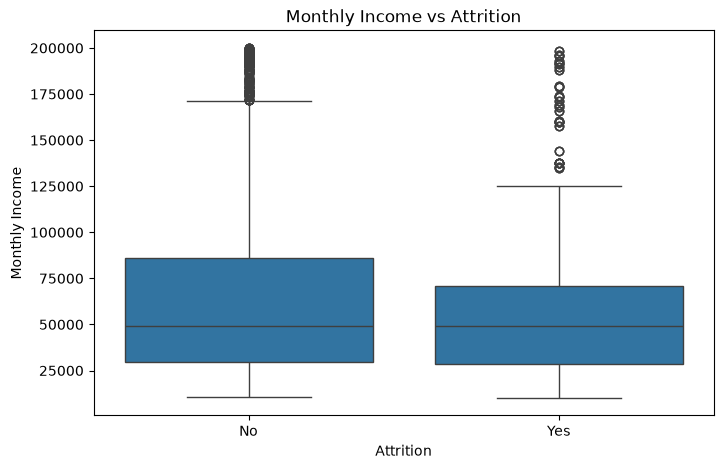

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

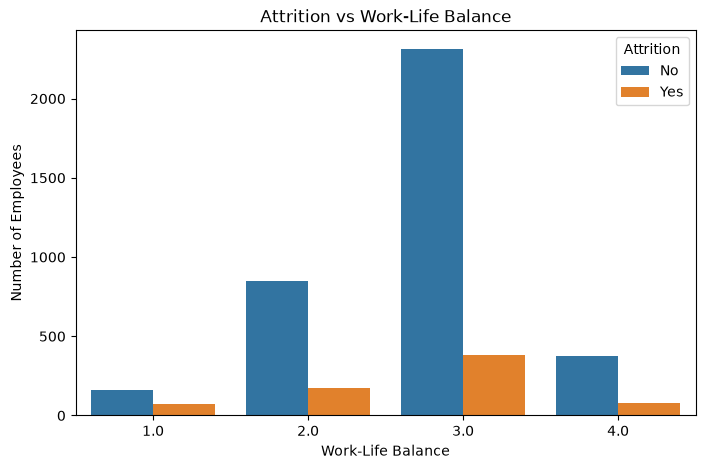

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="WorkLifeBalance", hue="Attrition")

plt.title("Attrition vs Work-Life Balance")
plt.xlabel("Work-Life Balance")
plt.ylabel("Number of Employees")
plt.show()

In [18]:
[col for col in df.columns if "over" in col.lower()]

['Over18']

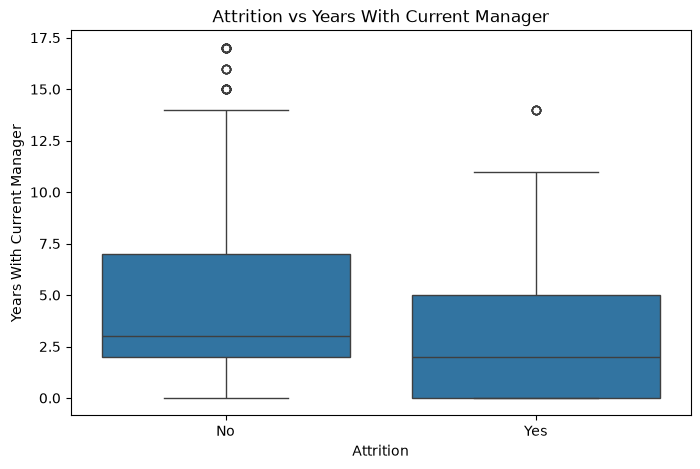

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Attrition", y="YearsWithCurrManager")

plt.title("Attrition vs Years With Current Manager")
plt.xlabel("Attrition")
plt.ylabel("Years With Current Manager")
plt.show()

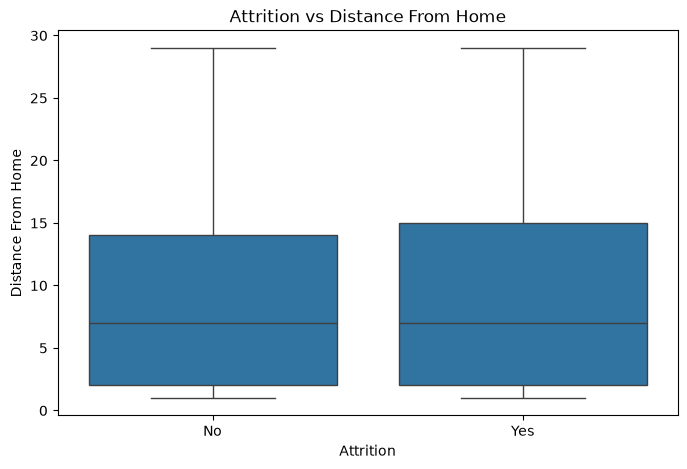

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Attrition", y="DistanceFromHome")

plt.title("Attrition vs Distance From Home")
plt.xlabel("Attrition")
plt.ylabel("Distance From Home")
plt.show()

In [21]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

df["Attrition"].value_counts()

Attrition
0    3699
1     711
Name: count, dtype: int64

In [22]:
categorical_cols = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_cols.tolist())

Categorical columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18']


In [23]:
# Remove the unnecessary column
df = df.drop(columns=["Over18"])

# Separate input features and target
X = df.drop(columns=["Attrition"])
y = df["Attrition"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4410, 27)
y shape: (4410,)


In [24]:
X = pd.get_dummies(X, columns=categorical_cols.drop("Over18"), drop_first=True)

print("New X shape:", X.shape)
print(X.head())

New X shape: (4410, 41)
   EmployeeID  Age  DistanceFromHome  Education  EmployeeCount  JobLevel  \
0           1   51                 6          2              1         1   
1           2   31                10          1              1         1   
2           3   32                17          4              1         4   
3           4   38                 2          5              1         3   
4           5   32                10          1              1         1   

   MonthlyIncome  NumCompaniesWorked  PercentSalaryHike  StandardHours  ...  \
0         131160                 1.0                 11              8  ...   
1          41890                 0.0                 23              8  ...   
2         193280                 1.0                 15              8  ...   
3          83210                 3.0                 11              8  ...   
4          23420                 4.0                 12              8  ...   

   JobRole_Human Resources  JobRole_Laborato

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3528, 41)
Testing data: (882, 41)


In [26]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [27]:
y_pred = model.predict(X_test)

print("Predictions generated!")
print(y_pred[:20])

Predictions generated!
[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]


In [28]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

Accuracy : 85.03 %
Precision: 77.78 %
Recall   : 9.86 %
F1 Score : 17.5 %


In [29]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[736   4]
 [128  14]]


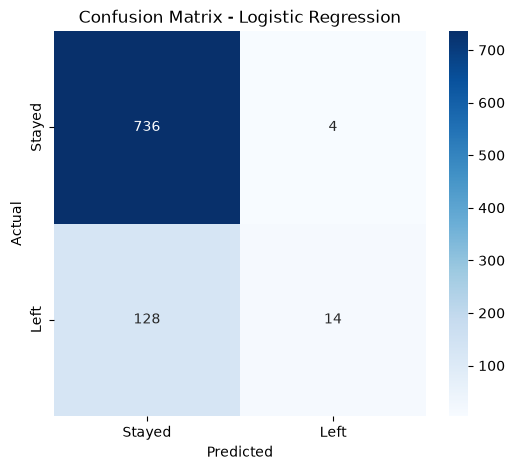

In [30]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_model.fit(X_train, y_train)

print("Balanced model training completed!")

Balanced model training completed!


In [32]:
y_pred_balanced = balanced_model.predict(X_test)

print("Predictions generated!")

Predictions generated!


In [33]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)

print("Balanced Model Results")
print("----------------------")
print("Accuracy :", round(accuracy_balanced * 100, 2), "%")
print("Precision:", round(precision_balanced * 100, 2), "%")
print("Recall   :", round(recall_balanced * 100, 2), "%")
print("F1 Score :", round(f1_balanced * 100, 2), "%")

Balanced Model Results
----------------------
Accuracy : 69.05 %
Precision: 29.07 %
Recall   : 64.08 %
F1 Score : 40.0 %


In [34]:
print("Comparison")
print("----------------------")
print(f"Accuracy:  {accuracy*100:.2f}%  →  {accuracy_balanced*100:.2f}%")
print(f"Precision: {precision*100:.2f}%  →  {precision_balanced*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%  →  {recall_balanced*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%  →  {f1_balanced*100:.2f}%")

Comparison
----------------------
Accuracy:  85.03%  →  69.05%
Precision: 77.78%  →  29.07%
Recall:    9.86%  →  64.08%
F1 Score:  17.50%  →  40.00%


In [35]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [36]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [37]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("----------------------")
print("Accuracy :", round(accuracy_dt * 100, 2), "%")
print("Precision:", round(precision_dt * 100, 2), "%")
print("Recall   :", round(recall_dt * 100, 2), "%")
print("F1 Score :", round(f1_dt * 100, 2), "%")

Decision Tree Results
----------------------
Accuracy : 75.62 %
Precision: 34.6 %
Recall   : 57.75 %
F1 Score : 43.27 %


In [38]:
drop_cols = ["EmployeeID", "EmployeeCount", "StandardHours"]

df_model = df.drop(columns=drop_cols)

print(df_model.shape)
print(df_model.columns.tolist())

(4410, 25)
['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating']


In [39]:
X_final = df_model.drop(columns=["Attrition"])
y_final = df_model["Attrition"]

# Encode target
y_final = y_final.map({"Yes": 1, "No": 0})

# Identify categorical columns
categorical_final = X_final.select_dtypes(include="object").columns

# One-hot encode
X_final = pd.get_dummies(
    X_final,
    columns=categorical_final,
    drop_first=True
)

print("X shape:", X_final.shape)
print("y shape:", y_final.shape)

X shape: (4410, 38)
y shape: (4410,)


In [40]:
X_final = df_model.drop(columns=["Attrition"])
y_final = df_model["Attrition"]

print(y_final.value_counts())
print(y_final.isna().sum())

Attrition
0    3699
1     711
Name: count, dtype: int64
0


In [41]:
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

print("Training:", X_train_final.shape)
print("Testing :", X_test_final.shape)

Training: (3528, 24)
Testing : (882, 24)


In [42]:
X_final = df_model.drop(columns=["Attrition"])
y_final = df_model["Attrition"]

# Find categorical columns
categorical_final = X_final.select_dtypes(include="object").columns

# Convert categorical columns into numerical columns
X_final = pd.get_dummies(
    X_final,
    columns=categorical_final,
    drop_first=True
)

print("X shape:", X_final.shape)
print("Categorical columns encoded:", list(categorical_final))

X shape: (4410, 38)
Categorical columns encoded: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


In [43]:
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

print("Training:", X_train_final.shape)
print("Testing :", X_test_final.shape)

Training: (3528, 38)
Testing : (882, 38)


In [44]:
final_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X_train_final, y_train_final)

y_pred_final = final_model.predict(X_test_final)

print("Final model trained successfully!")
print("Predictions:", len(y_pred_final))

Final model trained successfully!
Predictions: 882


In [45]:
accuracy_final = accuracy_score(y_test_final, y_pred_final)
precision_final = precision_score(y_test_final, y_pred_final)
recall_final = recall_score(y_test_final, y_pred_final)
f1_final = f1_score(y_test_final, y_pred_final)

print("FINAL DECISION TREE RESULTS")
print("----------------------------")
print("Accuracy :", round(accuracy_final * 100, 2), "%")
print("Precision:", round(precision_final * 100, 2), "%")
print("Recall   :", round(recall_final * 100, 2), "%")
print("F1 Score :", round(f1_final * 100, 2), "%")

FINAL DECISION TREE RESULTS
----------------------------
Accuracy : 75.62 %
Precision: 34.6 %
Recall   : 57.75 %
F1 Score : 43.27 %


In [46]:
import joblib

joblib.dump(final_model, "attrition_model.pkl")
joblib.dump(X_final.columns.tolist(), "model_columns.pkl")

print("Model saved successfully!")
print("Feature columns saved successfully!")

Model saved successfully!
Feature columns saved successfully!
